In [154]:
import numpy as np, matplotlib.pyplot as plt, sympy as sp

In [155]:
#1a
Q = np.array([
    [-1,1,0,0],
    [0,-1,1,0],
    [0,0,-1,1],
    [1,0,0,-1]
])
np.linalg.eig(Q)[0]

array([-2.00000000e+00+0.j, -1.00000000e+00+1.j, -1.00000000e+00-1.j,
       -1.87323557e-16+0.j])

In [156]:
A = np.array([
    [-1,0,0,1],
    [1,-1,0,0],
    [0,1,-1,0],
    [1,1,1,1]
])
b = np.array([0,0,0,1])
np.linalg.solve(A, b)

array([0.25, 0.25, 0.25, 0.25])

In [ ]:
#1d
t = sp.symbols('t', real=True)
Q = sp.Matrix([
    [-1, 1, 0, 0],
    [0, -1, 1, 0],
    [0, 0, -1, 1],
    [1, 0, 0, -1]
])
y0 = sp.Matrix([sp.Rational(1,3), sp.Rational(2,3), 0, 0])
y = sp.exp(Q.T * t) * y0
y1 = sp.simplify(y[0])
y1

(2*(-2*sin(t) + cos(t))*exp(t) + 3*exp(2*t) - 1)*exp(-2*t)/12

In [158]:
#1e
y1_func = sp.lambdify(t, y1, 'numpy')

def simulate_fraction(N, t_vals):
    results = []
    for t in t_vals:
        X0 = np.where(np.random.rand(N) < 1/3, 1, 2)
        jumps = np.random.poisson(t, size=N)
        Xt = ((X0 - 1 + jumps) % 4) + 1
        results.append(np.mean(Xt == 1))
    return np.array(results)

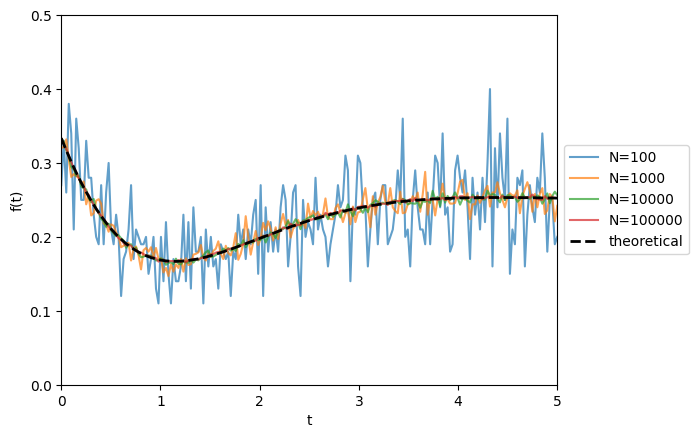

In [159]:
t_vals = np.linspace(0, 5, 200)
plt.figure()
for N in [100, 1000, 10000, 100000]:
    f_vals = simulate_fraction(N, t_vals)
    plt.plot(t_vals, f_vals, label=f"N={N}", alpha=0.7)
plt.plot(t_vals, y1_func(t_vals), 'k--', linewidth=2, label="theoretical")
plt.xlim(0,5)
plt.ylim(0,0.5)
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.xlabel("t")
plt.ylabel("f(t)")
plt.savefig('figures/1e_1.png', dpi = 300, bbox_inches = 'tight')

In [160]:
#2b
pi_F, pi_N, pi_D = sp.symbols('pi_F pi_N pi_D')
lambda_N, lambda_D, mu_N, mu_D = sp.symbols('lambda_N lambda_D mu_N mu_D')
pi = sp.Matrix([pi_F, pi_N, pi_D])
A = sp.Matrix([
    [lambda_N, -mu_N, 0],
    [lambda_D, 0, -mu_D],
    [1,        1,     1]
])
b = sp.Matrix([0, 0, 1])
solution = A.LUsolve(b)
solution_simplified = sp.simplify(solution)
solution_simplified

Matrix([
[    mu_D*mu_N/(lambda_D*mu_N + lambda_N*mu_D + mu_D*mu_N)],
[lambda_N*mu_D/(lambda_D*mu_N + lambda_N*mu_D + mu_D*mu_N)],
[lambda_D*mu_N/(lambda_D*mu_N + lambda_N*mu_D + mu_D*mu_N)]])

In [ ]:
#2c
Q = np.array([
    [-2, 1, 1],
    [1, -1, 0],
    [1, 0, -1]
])
np.linalg.eig(Q)

EigResult(eigenvalues=array([-3.00000000e+00,  2.22044605e-16, -1.00000000e+00]), eigenvectors=array([[-8.16496581e-01,  5.77350269e-01,  1.57009246e-16],
       [ 4.08248290e-01,  5.77350269e-01, -7.07106781e-01],
       [ 4.08248290e-01,  5.77350269e-01,  7.07106781e-01]]))